In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.interpolate import RegularGridInterpolator

# ...existing code...
with open('hms-nu-20-01-000.d') as f:
    lines = (line for line in f if 'average' not in line and 'Enu' not in line)
    all_flux_data = np.loadtxt(lines)  # Load all columns at once
    flux_data_numu = all_flux_data[:, [0, 1]]
    flux_data_numubar = all_flux_data[:, [0, 2]]
    flux_data_nue = all_flux_data[:, [0, 3]]
    flux_data_nuebar = all_flux_data[:, [0, 4]]
print(flux_data_numu.shape, flux_data_numubar.shape, flux_data_nue.shape, flux_data_nuebar.shape)
# ...rest of the cell unchanged...
# flux_data_numubar = np.loadtxt('hms-nu-20-01-000.d',
#                   usecols=[0, 2],)
# flux_data_nue = np.loadtxt('hms-nu-20-01-000.d',
#                   usecols=[0, 3],)
# flux_data_nuebar = np.loadtxt('hms-nu-20-01-000.d',
#                   usecols=[0, 4],)

# # cos [0.2, 0.3]
# data0 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 723,
#                   max_rows = 39)
# # cos [0.1, 0.2]
# data1 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 826,
#                   max_rows = 39)
# # cos [0, 0.1]
# data2 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 929,
#                   max_rows = 39)
# # cos [-0.1, 0]
# data3 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 1032,
#                   max_rows = 39)
# # cos [-0.2, -0.1]
# data4 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 1135,
#                   max_rows = 39)
# # cos [-0.3, -0.2]
# data5 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 1238,
#                   max_rows = 39)
# # cos [-0.4, -0.3]
# data6 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 1341,
#                   max_rows = 39)
# # cos [-0.5, -0.4]
# data7 = np.loadtxt('hms-nu-20-01-000.d', 
#                   usecols=[0, 1],
#                   skiprows = 1444,
#                   max_rows = 39)


(2020, 2) (2020, 2) (2020, 2) (2020, 2)


In [517]:
n_energy = 101
energies = all_flux_data[0:n_energy, 0]  # energies are the same for each block
num_cos = len(all_flux_data) // n_energy  # number of cos bins
flux_2d = np.zeros((num_cos, n_energy))
for i in range(num_cos):
    start = i * n_energy
    flux_2d[i, :] = all_flux_data[start:start + n_energy, 1]  # stack flux (column 1)

cos_bins_centers = np.linspace(-0.95, 0.95, num_cos)

coords = (cos_bins_centers, energies)
interpolator_regular = RegularGridInterpolator(coords, flux_2d, method='linear', bounds_error=False, fill_value=0)

# Alternative: Use RectBivariateSpline with lower degree (kx=1, ky=3 for linear in cos, cubic in energy)
from scipy.interpolate import RectBivariateSpline

try:
    # Use linear interpolation in cos direction (kx=1) since we have 4 points
    interpolator_2d = RectBivariateSpline(cos_bins_centers, energies, flux_2d, kx=1, ky=3)
    print("RectBivariateSpline created successfully with kx=1, ky=3")
except Exception as e:
    print(f"RectBivariateSpline failed: {e}")
    interpolator_2d = None

test_cos = -0.12
test_energy = 1.5

flux_interp_regular = interpolator_regular(np.array([test_cos, test_energy]))

print(f"Interpolated flux at cos={test_cos}, E={test_energy} GeV:")
print(f"RegularGridInterpolator: {flux_interp_regular[0]:.2e}")

if interpolator_2d is not None:
    # Using RectBivariateSpline
    flux_interp_spline = interpolator_2d(test_cos, test_energy)[0][0]
    print(f"RectBivariateSpline: {flux_interp_spline:.2e}")

# Create a function for easy evaluation
def get_flux(cos_theta, energy):
    points = np.column_stack([np.atleast_1d(cos_theta), np.atleast_1d(energy)])
    return interpolator_regular(points)

# Example usage
example_flux = get_flux(-0.18, 2.0)
print(f"Example: Flux at cos=-0.18, E=2.0 GeV: {example_flux[0]:.2e}")

RectBivariateSpline created successfully with kx=1, ky=3
Interpolated flux at cos=-0.12, E=1.5 GeV:
RegularGridInterpolator: 7.21e+01
RectBivariateSpline: 7.10e+01
Example: Flux at cos=-0.18, E=2.0 GeV: 3.26e+01


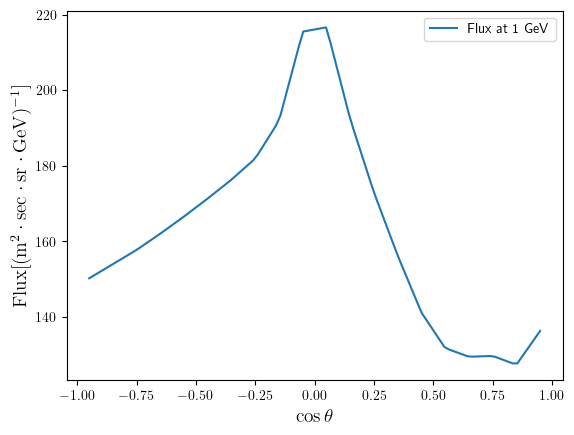

In [518]:
cos_grid = np.linspace(-0.95, 0.95, 100)
plt.plot(cos_grid, [get_flux(cos, energies[20])[0] for cos in cos_grid], label="Flux at 1 GeV")
plt.xlabel(r"$\cos\theta$", fontsize=14)
plt.ylabel(r"$\mathrm{Flux} [(\mathrm{m^2 \cdot sec \cdot sr \cdot GeV})^{-1}]$", fontsize=14)
plt.legend()
plt.savefig('flux_zenith.pdf', dpi=300)

In [33]:
np.pi/2/(1.27*2.5e-3)

494.7390005653217

Oscillation prob

In [119]:
s23 = 0.47 # sin^2(theta23)
s13 = 0.022 # sin^2(theta13)
dm31 = 2.5e-3 # eV^2
r_e = 6371 # earth radius in km
# def p_mumu(x, E):
#     # x is cos(theta), E is in GeV
#     L = -2*r_e*x
#     return 1-4*s23*(1-s23)*np.sin(1.27*dm23*L/E)**2

r = 6371 # km
d = 20
s = 1.5
def prop_length(x):
    # x is cos(theta)
    sqrt = np.sqrt(4*x**2*(s-r)**2-4*(s**2-2*r*s-d**2-2*r*d))
    return 1/2 * (-2*x*(r-s)+sqrt)

def baseline(x):
    if x < 0:
        L = -2*r*x
    else:
        L = prop_length(x)
    return L

def p_mumu_tf(x, E, baseline_type='cos'):
    # x is cos(theta), E is in GeV
    # numu to nutau only
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    return 1-4*s23*(1-s23)*np.sin(1.27*dm31*L/E)**2

def p_mumu_vac(x, E, baseline_type='cos'):
    # x is cos(theta), E is in GeV
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    phase = 1.27 * dm31 * L / E

    c13_sq = 1.0 - s13
    c13_4 = c13_sq**2

    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)
    sin2_2theta13 = 4.0 * s13 * (1.0 - s13)

    return 1.0 - c13_4 * sin2_2theta23 * np.sin(phase)**2 - s23 * sin2_2theta13 * np.sin(phase)**2

def p_mumu_matter(x, E, Ye = 0.5, rho = 2.8, baseline_type = 'cos'):
    """
    Calculate the muon neutrino survival probability in matter using a simplified 2-flavor approximation.

    Parameters: 
    - E: neutrino energy in GeV
    - x: baseline parameter (cosine of zenith angle or poropational length)
    - Ye: electron fraction in the Earth (default 0.5)
    - rho: matter density in g/cm^3 (default 2.8)
    - baseline_type: method to calculate baseline ('cos' for simple cosine approximation, 'km' for more accurate path length)
    Returns:
    - P_mumu: muon neutrino survival probability in matter
    """
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    # angles
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)

    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)
    sin2theta13 = 2.0 * s13v * c13v
    cos2theta13 = 1.0 - 2.0 * s13

    # matter potential in eV^2
    A = 2 * 7.56e-5 * Ye * rho * E

    # effective atmospheric splitting in matter
    dm31_m = np.sqrt((dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2)

    # matter-modified theta13
    sin2_2theta13_m = (dm31 * sin2theta13)**2 / (
        (dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2
    )

    cos2theta13_m = (dm31 * cos2theta13 - A) / dm31_m

    s13_m = 0.5 * (1.0 - cos2theta13_m)
    c13_m = 1.0 - s13_m

    # phases
    phase1 = 1.27 * (dm31 + A + dm31_m) * L / (2.0 * E)
    phase2 = 1.27 * (dm31 + A - dm31_m) * L / (2.0 * E)
    phase3 = 1.27 * dm31_m * L / E

    # terms
    term1 = c13_m * sin2_2theta23 * np.sin(phase1)**2
    term2 = s13_m * sin2_2theta23 * np.sin(phase2)**2
    term3 = (s23**2) * sin2_2theta13_m * np.sin(phase3)**2

    return 1.0 - term1 - term2 - term3

In [120]:
def p_mue_matter(x, E, Ye = 0.5, rho = 2.8, baseline_type = 'cos'):
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    
    # angles
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)

    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)
    sin2theta13 = 2.0 * s13v * c13v
    cos2theta13 = 1.0 - 2.0 * s13

    # matter potential in eV^2
    A = 2 * 7.56e-5 * Ye * rho * E

    # effective atmospheric splitting in matter
    dm31_m = np.sqrt((dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2)

    # matter-modified theta13
    sin2_2theta13_m = (dm31 * sin2theta13)**2 / (
        (dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2
    )

    return s23 * sin2_2theta13_m * np.sin(1.27 * dm31_m * L / E)**2

def p_mue_vac(x, E, baseline_type='cos'):
    # 2 level approximation for numu to nue appearance
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")

    return s23 * 4.0 * s13 * (1.0 - s13) * np.sin(1.27 * dm31 * L / E)**2


In [121]:
def p_mutau_vac(x, E, baseline_type='cos'):
    # 2 level approximation for numu to nutau appearance
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    
    # angles
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)
    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)

    return c13v**4 * sin2_2theta23 * np.sin(1.27 * dm31 * L / E)**2

def p_mutau_matter(x, E, Ye = 0.5, rho = 2.8, baseline_type = 'cos'):
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    # angles
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)

    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)
    sin2theta13 = 2.0 * s13v * c13v
    cos2theta13 = 1.0 - 2.0 * s13

    # matter potential in eV^2
    A = 2 * 7.56e-5 * Ye * rho * E

    # effective atmospheric splitting in matter
    dm31_m = np.sqrt((dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2)

    # matter-modified theta13
    sin2_2theta13_m = (dm31 * sin2theta13)**2 / (
        (dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2
    )

    cos2theta13_m = (dm31 * cos2theta13 - A) / dm31_m

    s13_m = 0.5 * (1.0 - cos2theta13_m)
    c13_m = 1.0 - s13_m

    # phases
    phase1 = 1.27 * (dm31 + A + dm31_m) * L / (2.0 * E)
    phase2 = 1.27 * (dm31 + A - dm31_m) * L / (2.0 * E)
    phase3 = 1.27 * dm31_m * L / E

    # terms
    term1 = c13_m * sin2_2theta23 * np.sin(phase1)**2
    term2 = s13_m * sin2_2theta23 * np.sin(phase2)**2
    term3 = sin2_2theta23 * sin2_2theta13_m/4 * np.sin(phase3)**2

    return term1 + term2 - term3

Xsec

In [521]:
import uproot

energy_bins = np.linspace(0.5, 8.0, 62)
energy_bins_centers = (energy_bins[:-1] + energy_bins[1:]) / 2
# Load the ROOT file
file = uproot.open("xsec_graphs.root")

# access the specific graph
graph = file["nu_mu_Ar40"]["tot_cc;1"]
# Extract the x and y values from the graph
x_values = graph.member("fX")
y_values = graph.member("fY")
inter_xy = interp.interp1d(x_values, y_values, bounds_error=False, fill_value=0)
# save it to text
np.savetxt('xsec.txt',inter_xy(energy_bins_centers),)

In [522]:
# xsec = inter_xy(energy_bins_centers)
# # 10^-38 cm^2 to m^2
# conv = 1e-38 * 1e-4  # cm^2 to m^2
# # number of argons for 20 kt FD
# noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
# scaled_xsec = conv*noar*xsec

# # Integrate cos to get the total event rate
# from scipy.integrate import simpson

# # Create integration grid for cos(theta)
# cos_grid_1 = np.linspace(-0.273, 0, 100)
# cos_grid_2 = np.linspace(0, 0.0708, 50)

# # Calculate event rate for each energy bin
# event_rate = np.zeros(len(energy_bins_centers))
# event_rate_unosc = np.zeros(len(energy_bins_centers))

# # Time factor: 3 years in seconds
# time_factor = 3 * 365.25 * 24 * 3600  # 3 years in seconds

# # Energy bin width
# energy_bin_width = energy_bins[1] - energy_bins[0]

# for i, E in enumerate(energy_bins_centers):
#     # Get flux, oscillation probability, and cross section for this energy
#     flux_values1 = np.array([get_flux(cos, E)[0] for cos in cos_grid_1])
#     flux_values2 = np.array([get_flux(cos, E)[0] for cos in cos_grid_2])
#     flux_values = np.concatenate((flux_values1, flux_values2))
#     osc_prob = p_mumu(cos_grid_1, E)
    
#     # Integrand with oscillation: flux * p_mumu * xsec * 2pi (azimuthal integration) * time * dE
#     integrand_osc_1 = flux_values1 * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
#     integrand_osc_2 = flux_values2 * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
#     integrand_osc = np.concatenate((integrand_osc_1, integrand_osc_2))
#     # Integrand without oscillation: flux * xsec * 2pi * time * dE
#     integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
#     # Integrate over cos(theta)
#     event_rate[i] = simpson(integrand_osc, np.concatenate((cos_grid_1, cos_grid_2)))
#     event_rate_unosc[i] = simpson(integrand_unosc, np.concatenate((cos_grid_1, cos_grid_2)))

# print(f"Total event rate over 3 years (oscillated): {np.sum(event_rate):.2f} events")
# print(f"Total event rate over 3 years (unoscillated): {np.sum(event_rate_unosc):.2f} events")
# print(f"Average per year (oscillated): {np.sum(event_rate)/3:.2f} events/year")
# print(f"Average per year (unoscillated): {np.sum(event_rate_unosc)/3:.2f} events/year")
# print(f"Energy bin width: {energy_bin_width:.3f} GeV")

# # For histogram plotting
# energy_bins_edges = energy_bins

In [523]:
# # latex
# plt.rcParams['text.usetex'] = True
# plt.figure(figsize=(10, 6))
# plt.hist(energy_bins_centers, weights=event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r'Unoscillated $\nu_\mu$', linewidth=2)
# plt.hist(energy_bins_centers, weights=event_rate, bins=energy_bins_edges, histtype="step", label=r'Oscillated $\nu_\mu$', linewidth=2, color = 'black')
# #plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r'oscillated/unoscillated', linewidth=2)
# # error bars
# plt.errorbar(energy_bins_centers, event_rate, yerr=np.sqrt(event_rate), fmt='o', color='black')
# plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
# plt.ylabel("Event Rate", fontsize=14)
# plt.xlim(0.5, 8)
# plt.legend(fontsize=12)
# plt.title(r"Expected $\nu_\mu$ Event Rate in zenith band $-0.273 < \cos\theta < 0.0708$ (3 years)", fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.show()
# print(f"Total events (oscillated): {np.sum(event_rate):.2f}")
# print(f"Total events (unoscillated): {np.sum(event_rate_unosc):.2f}")

Conclusion: It's sensitive to theta23 but not delta m^2
try different zenith band

In [524]:
# xsec = inter_xy(energy_bins_centers)
# # 10^-38 cm^2 to m^2
# conv = 1e-38 * 1e-4  # cm^2 to m^2
# # number of argons for 20 kt FD
# noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
# scaled_xsec = conv*noar*xsec

# # Integrate cos to get the total event rate
# from scipy.integrate import simpson

# # Create integration grid for cos(theta)
# cos_grid = np.linspace(-0.119, -0.084, 100)

# # Calculate event rate for each energy bin
# event_rate = np.zeros(len(energy_bins_centers))
# event_rate_unosc = np.zeros(len(energy_bins_centers))

# # Time factor: 3 years in seconds
# time_factor = 3 * 365.25 * 24 * 3600  # 3 years in seconds

# # Energy bin width
# energy_bin_width = energy_bins[1] - energy_bins[0]

# for i, E in enumerate(energy_bins_centers):
#     # Get flux, oscillation probability, and cross section for this energy
#     flux_values = np.array([get_flux(cos, E)[0] for cos in cos_grid])
#     osc_prob = p_mumu(cos_grid_1, E)
    
#     # Integrand with oscillation: flux * p_mumu * xsec * 2pi (azimuthal integration) * time * dE
#     integrand_osc = flux_values * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
#     # Integrand without oscillation: flux * xsec * 2pi * time * dE
#     integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
#     # Integrate over cos(theta)
#     event_rate[i] = simpson(integrand_osc, cos_grid)
#     event_rate_unosc[i] = simpson(integrand_unosc, cos_grid)
# print(f"Total event rate over 3 years (oscillated): {np.sum(event_rate):.2f} events")
# print(f"Total event rate over 3 years (unoscillated): {np.sum(event_rate_unosc):.2f} events")
# print(f"Average per year (oscillated): {np.sum(event_rate)/3:.2f} events/year")
# print(f"Average per year (unoscillated): {np.sum(event_rate_unosc)/3:.2f} events/year")
# print(f"Energy bin width: {energy_bin_width:.3f} GeV")

# # For histogram plotting
# energy_bins_edges = energy_bins

# # latex
# plt.rcParams['text.usetex'] = True
# plt.figure(figsize=(10, 6))
# #plt.hist(energy_bins_centers, weights=event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r'Unoscillated $\nu_\mu$', linewidth=2)
# #plt.hist(energy_bins_centers, weights=event_rate, bins=energy_bins_edges, histtype="step", label=r'Oscillated $\nu_\mu$', linewidth=2, color = 'black')
# plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r'oscillated/unoscillated', linewidth=2)
# # error bars
# #plt.errorbar(energy_bins_centers, event_rate, yerr=np.sqrt(event_rate), fmt='o', color='black')
# plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
# plt.ylabel("Event Rate", fontsize=14)
# plt.xlim(0.5, 8)
# plt.legend(fontsize=12)
# plt.title(r"Expected $\nu_\mu$ Event Rate in zenith band $-0.119 < \cos\theta < -0.084$ (3 year, 20 kt)", fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.show()
# print(f"Total events (oscillated): {np.sum(event_rate):.2f}")
# print(f"Total events (unoscillated): {np.sum(event_rate_unosc):.2f}")

## People need to breath so let's have atmosphere
Thickness of the atmosphere (height of production): d \
Radius of earth: r \
Propogation length: h 

In [525]:
prop_length(1)

np.float64(21.5)

Energy bin width: 0.123 GeV
Total events (oscillated): 926.33
Total events (unoscillated): 1610.26


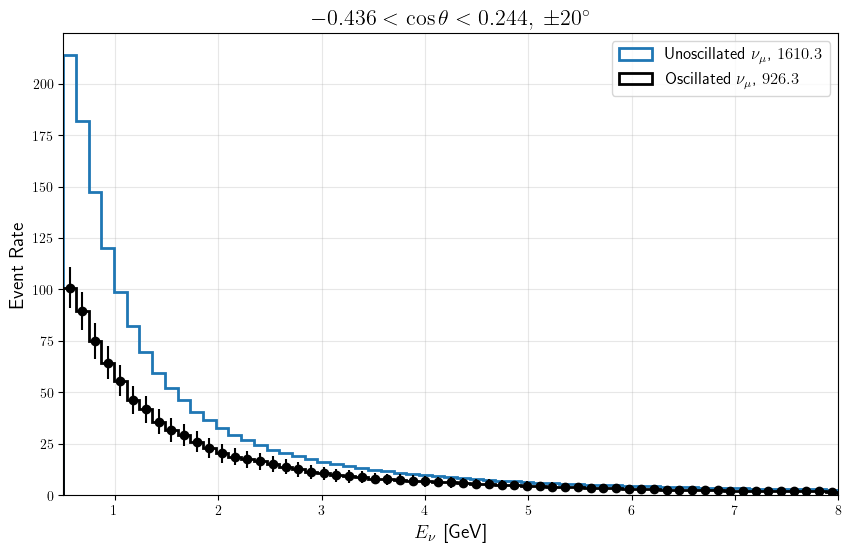

In [526]:
plot_ratio = False
delta_theta = 20
xsec = inter_xy(energy_bins_centers)
# 10^-38 cm^2 to m^2
conv = 1e-38 * 1e-4  # cm^2 to m^2
# number of argons for 20 kt FD
noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
scaled_xsec = conv*noar*xsec

# Integrate cos to get the total event rate
from scipy.integrate import simpson

def cos_lim(delta_theta):
    theta_0 = 95.85
    return (np.cos(np.radians(theta_0+delta_theta)), np.cos(np.radians(theta_0-delta_theta)))
cos_limit = cos_lim(delta_theta)
# Create integration grid for cos(theta)
cos_grid = np.linspace(cos_limit[0], cos_limit[1], 100)

# Calculate event rate for each energy bin
event_rate = np.zeros(len(energy_bins_centers))
event_rate_unosc = np.zeros(len(energy_bins_centers))

time_factor = 3 * 365.25 * 24 * 3600  # 3 years in seconds

# Energy bin width
energy_bin_width = energy_bins[1] - energy_bins[0]

for i, E in enumerate(energy_bins_centers):
    # Get flux, oscillation probability, and cross section for this energy
    flux_values = np.array([get_flux(cos, E)[0] for cos in cos_grid])
    osc_prob = np.array([p_mumu_vac(cos, E) for cos in cos_grid])
    
    # Integrand with oscillation: flux * p_mumu * xsec * 2pi (azimuthal integration) * time * dE
    integrand_osc = flux_values * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    # Integrand without oscillation: flux * xsec * 2pi * time * dE
    integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
    # Integrate over cos(theta)
    event_rate[i] = simpson(integrand_osc, cos_grid)
    event_rate_unosc[i] = simpson(integrand_unosc, cos_grid)

print(f"Energy bin width: {energy_bin_width:.3f} GeV")

# For histogram plotting
energy_bins_edges = energy_bins
# latex

plt.rcParams['text.usetex'] = True
plt.figure(figsize=(10, 6))
if plot_ratio is True:
    plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r'oscillated/unoscillated', linewidth=2)
    plt.ylabel(r"$P_{\mu\mu}^{\mathrm{eff}}$", fontsize=14)
else:
    plt.hist(energy_bins_centers, weights=event_rate_unosc, bins=energy_bins_edges, histtype="step", label=rf'Unoscillated $\nu_\mu$, ${np.sum(event_rate_unosc):.1f}$', linewidth=2)
    plt.hist(energy_bins_centers, weights=event_rate, bins=energy_bins_edges, histtype="step", label=rf'Oscillated $\nu_\mu$, ${np.sum(event_rate):.1f}$', linewidth=2, color = 'black')
    plt.errorbar(energy_bins_centers, event_rate, yerr=np.sqrt(event_rate), fmt='o', color='black')
    plt.ylabel("Event Rate", fontsize=14)

plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.title(rf"${cos_limit[0]:.3f} < \cos\theta < {cos_limit[1]:.3f},\; \pm {delta_theta}^\circ$", fontsize=16)
plt.grid(True, alpha=0.3)

plt.savefig(f"event_rate_with_atmos_+-{delta_theta}.pdf", dpi=300)
print(f"Total events (oscillated): {np.sum(event_rate):.2f}")
print(f"Total events (unoscillated): {np.sum(event_rate_unosc):.2f}")

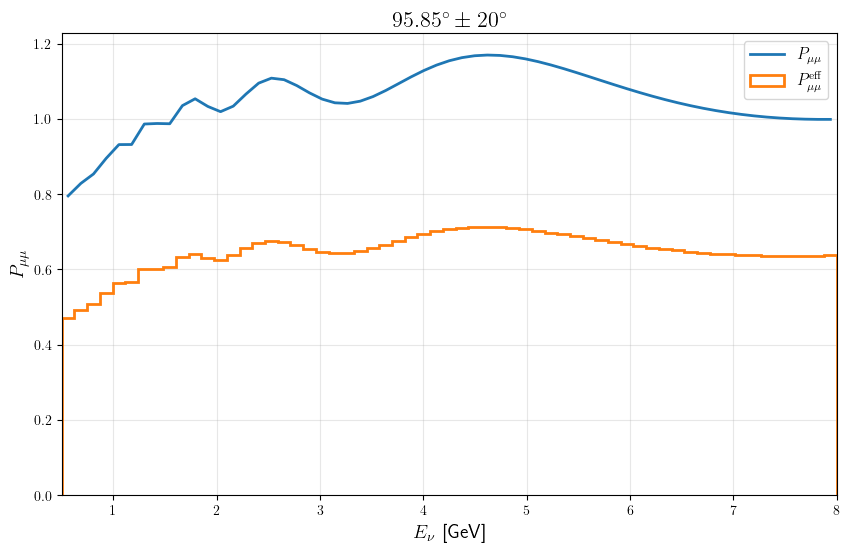

In [527]:

# def p_mumu_l(L,E):
#     return 1-4*s23*(1-s23)*np.sin(1.27*dm23*L/E)**2
# L_range = (np.abs(2*6371*np.cos(np.radians(95.85-delta_theta))), np.abs(2*6371*np.cos(np.radians(95.85+delta_theta))))
# if delta_theta > 5.85:
#     L_range = (0, L_range[1])
# print(f"L range: {L_range[0]:.1f} km to {L_range[1]:.1f} km")
# L_array = np.linspace(L_range[0], L_range[1], 100)
p_mm = np.zeros(len(energy_bins_centers))
for i in range(len(cos_grid)):
    p_mm += p_mumu_vac(cos_grid[i], energy_bins_centers)
plt.figure(figsize=(10, 6))
plt.plot(energy_bins_centers, p_mm/len(energy_bins_centers), label=r'$P_{\mu\mu}$', linewidth=2)
plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r"$P_{\mu\mu}^{\mathrm{eff}}$", linewidth=2)
plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(fr'$95.85^\circ \pm {delta_theta}^\circ$', fontsize=16)
plt.savefig(f"p_mumu_cos_{cos_limit[0]:.3f}_{cos_limit[1]:.3f}.pdf", dpi=300)

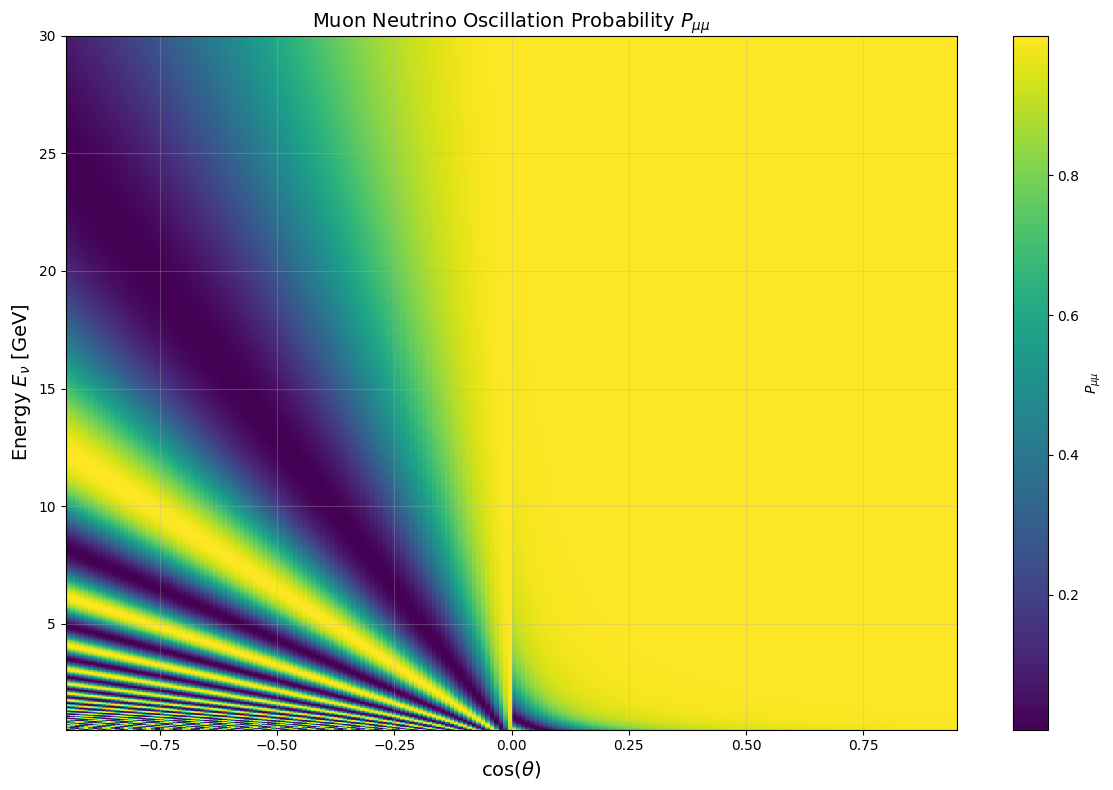

Probability range: 0.0065 to 1.0000


In [88]:

# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
# energies_for_heatmap = energy_bins_centers
energies_for_heatmap = np.linspace(0.5, 30, 1000)
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = p_mumu_vac(cos_z, E)

# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
#plt.yscale('log')
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu\mu}$', fontsize=14)

cbar = plt.colorbar(im, label=r'$P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_oscillogram.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


With matter effect

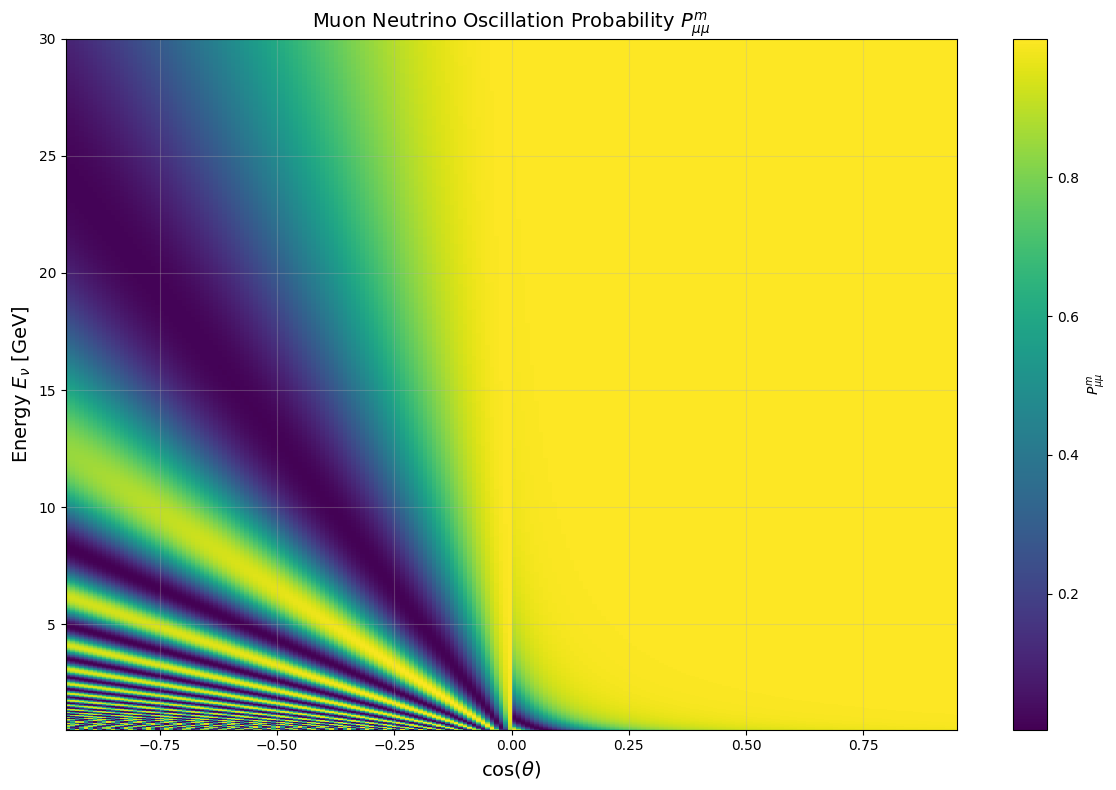

Probability range: 0.0036 to 1.0000


In [91]:

# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
#energies_for_heatmap = energy_bins_centers
energies_for_heatmap = np.linspace(0.5, 30, 1000)
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = p_mumu_matter(cos_z,E, Ye = 0.5, rho =2.8, baseline_type='cos')

# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu\mu}^m$', fontsize=14)

cbar = plt.colorbar(im, label=r'$P_{\mu\mu}^m$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_matter_oscillogram_2.8.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


Difference between the two

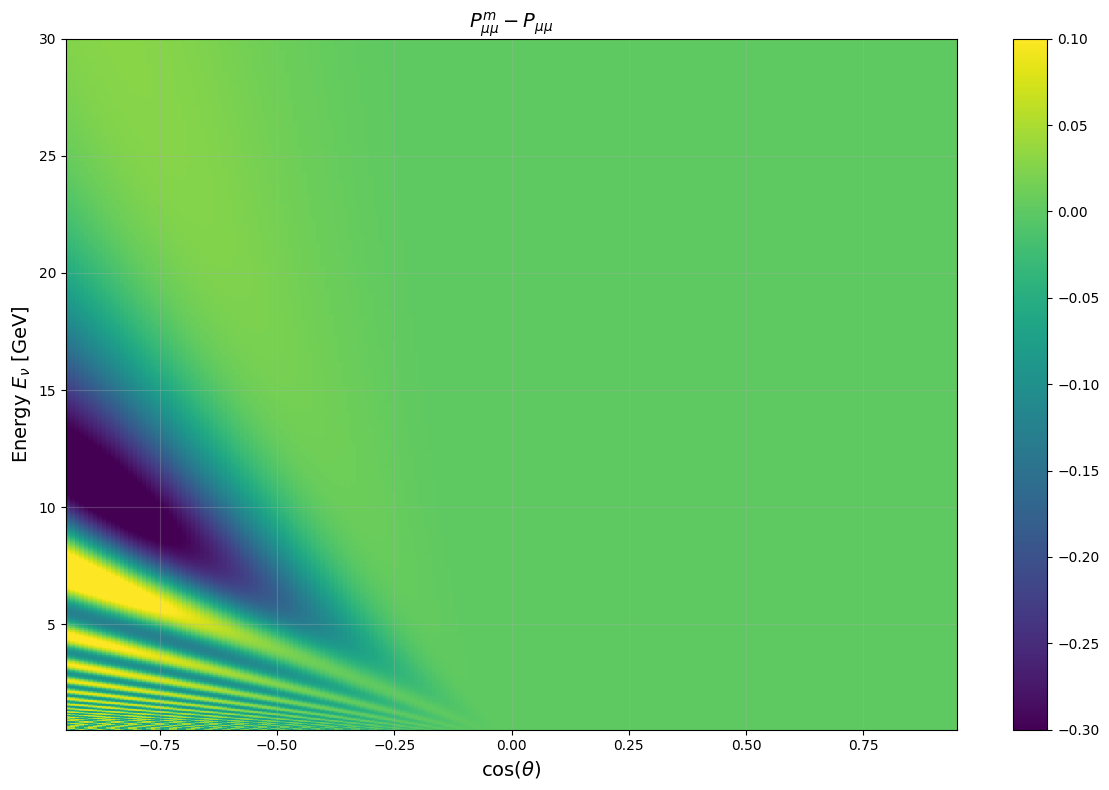

Probability range: -0.3464 to 0.1824


In [124]:

# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
# energies_for_heatmap = energy_bins_centers
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = p_mumu_matter(cos_z, E, Ye = 0.5, rho =2.8, baseline_type='cos')-p_mumu_vac(cos_z, E)
prob_min = prob_grid.min()
prob_max = prob_grid.max()
# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest',  vmin = -0.3, vmax = 0.1)

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
#plt.yscale('log')
plt.title(r'$P_{\mu\mu}^m - P_{\mu\mu}$', fontsize=14)

cbar = plt.colorbar(im)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_oscillogram_diff.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


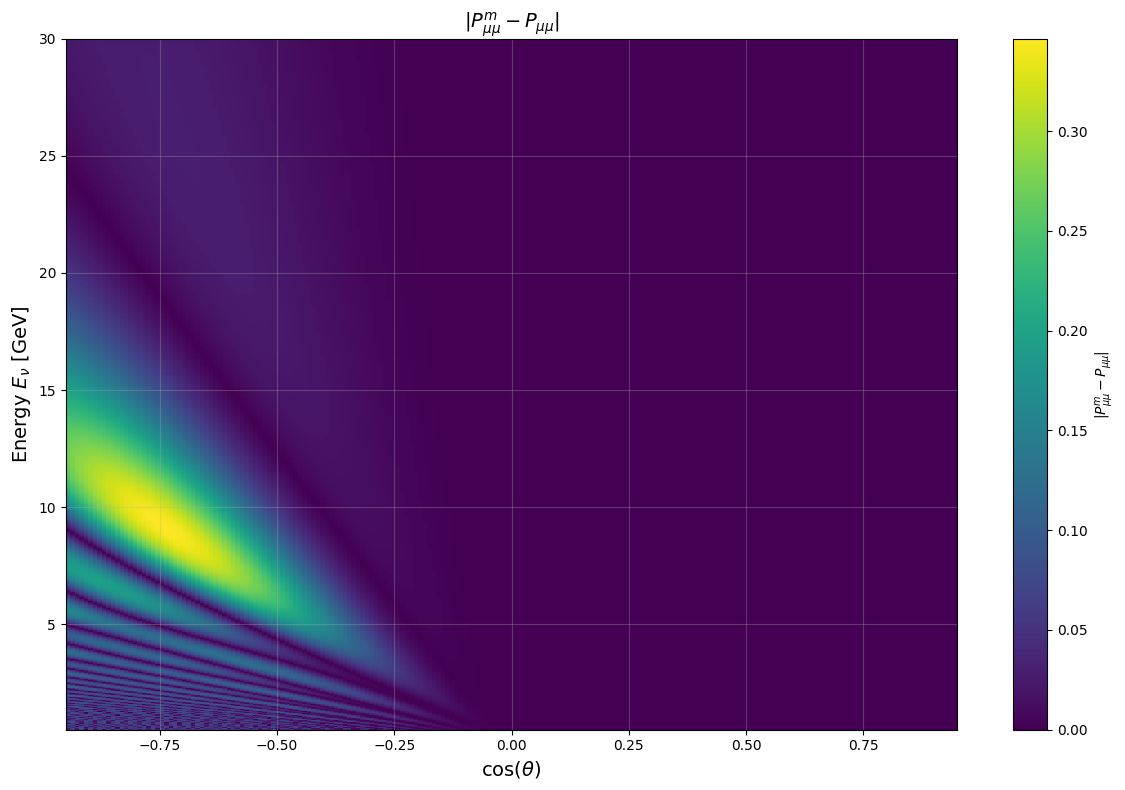

Probability range: 0.0000 to 0.3464


In [93]:
# absolute difference
# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
# energies_for_heatmap = energy_bins_centers
energies_for_heatmap = np.linspace(0.5, 30, 1000)
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = np.abs(p_mumu_vac(cos_z, E)-p_mumu_matter(cos_z, E, Ye = 0.5, rho = 6.7, baseline_type='cos'))

# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
#plt.yscale('log')
plt.title(r'$|P_{\mu\mu}^m - P_{\mu\mu}|$', fontsize=14)

cbar = plt.colorbar(im, label=r'$|P_{\mu\mu}^m - P_{\mu\mu}|$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_oscillogram_diff_abs.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


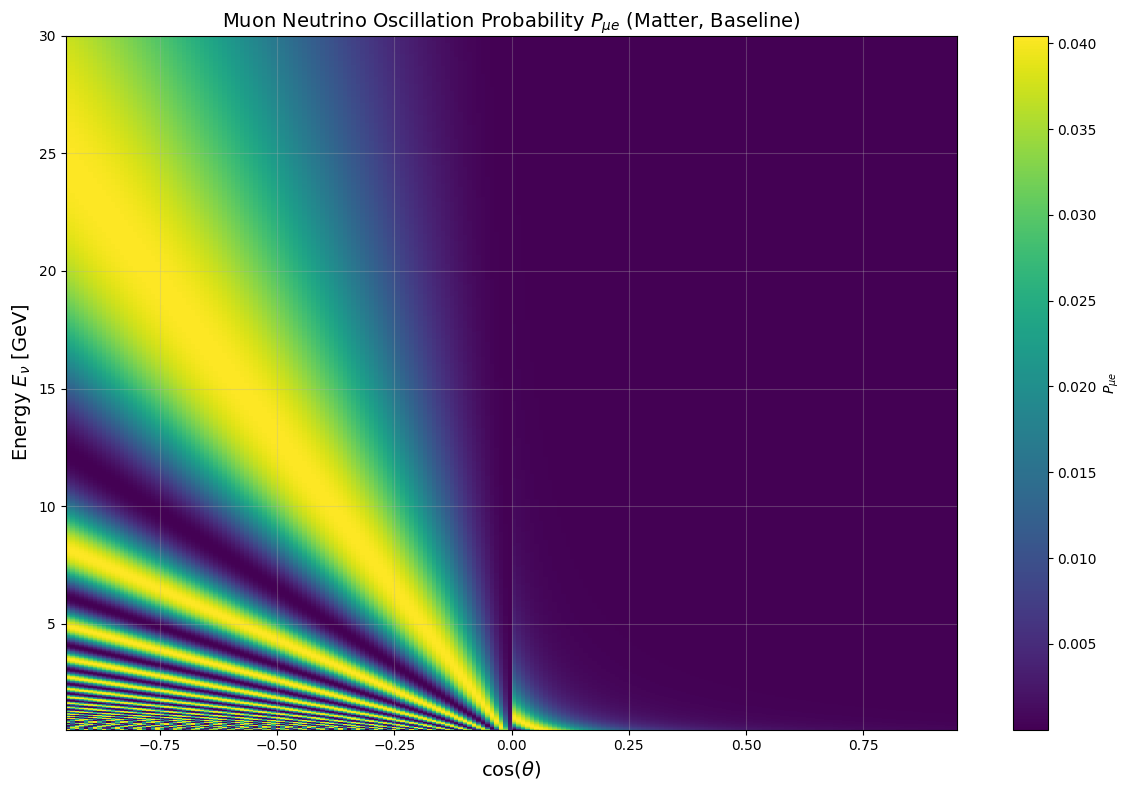

In [94]:
# vacuum appearance probability heatmap in cos(theta) vs energy
zenith_angles = np.linspace(-0.95, 0.95, 200)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = p_mue_vac(L, E, baseline_type='cos')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$ (Matter, Baseline)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('p_mue_matter_oscillogram_km.pdf', dpi=300)
plt.show()

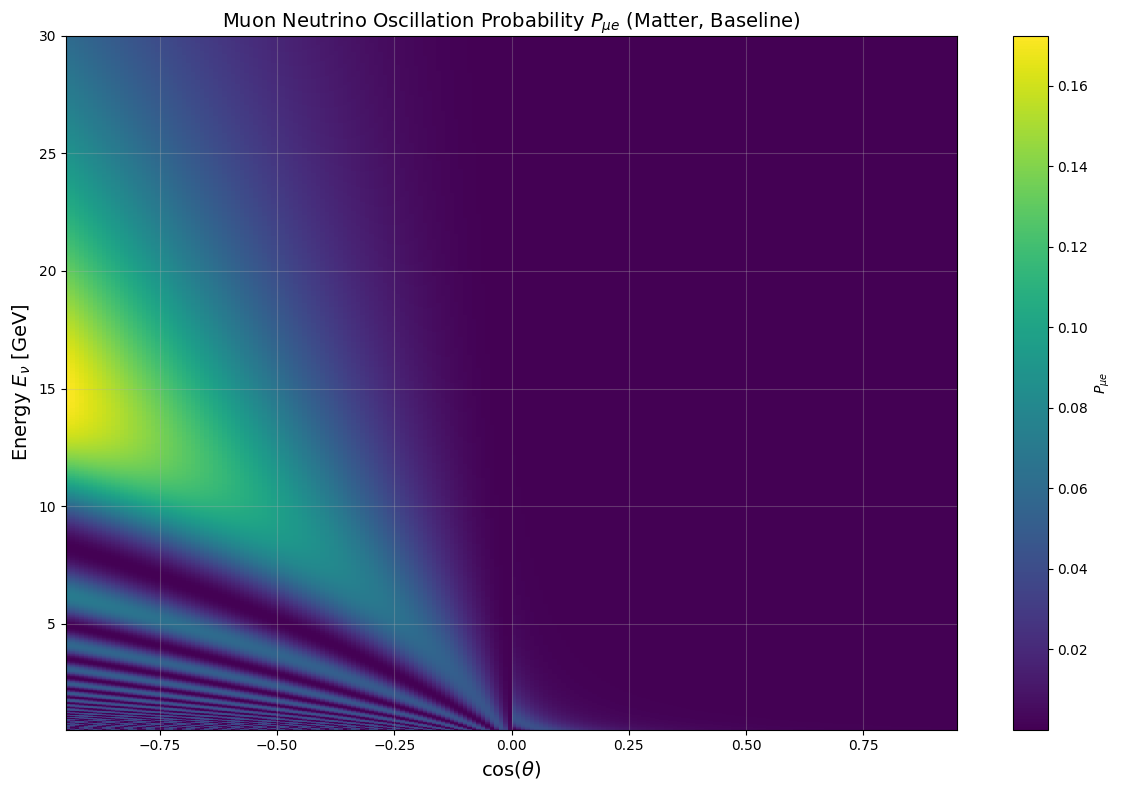

In [95]:
# Do the same thing but for baseline in km instead of cos(theta)
zenith_angles = np.linspace(-0.95, 0.95, 200)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = p_mue_matter(L, E, Ye=0.5, rho=2.8, baseline_type='cos')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$ (Matter, Baseline)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('p_mue_matter_oscillogram_km.pdf', dpi=300)
plt.show()

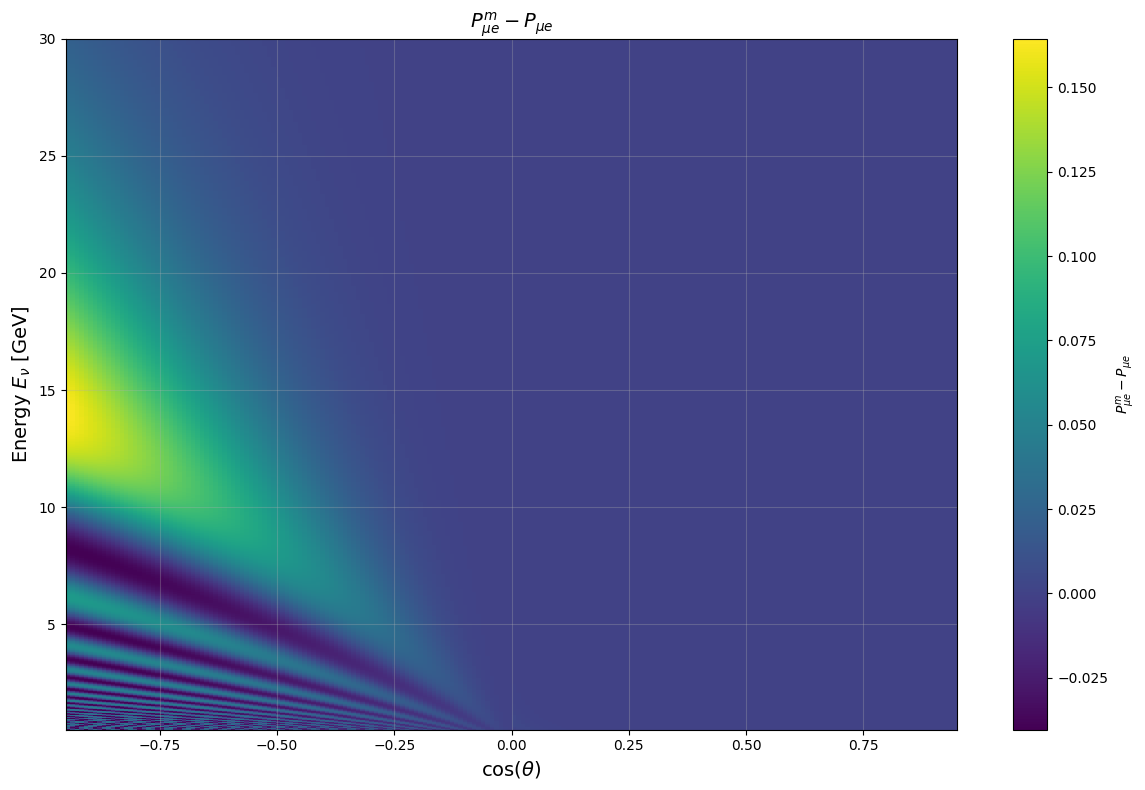

In [108]:
# Do the same thing but for baseline in km instead of cos(theta)
zenith_angles = np.linspace(-0.95, 0.95, 200)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = p_mue_matter(L, E, Ye=0.5, rho=2.8, baseline_type='cos')-p_mue_vac(L, E, baseline_type='cos')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'$P_{\mu e}^m - P_{\mu e}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}^m - P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mue_matter_oscillogram_diff.pdf', dpi=300)
plt.show()

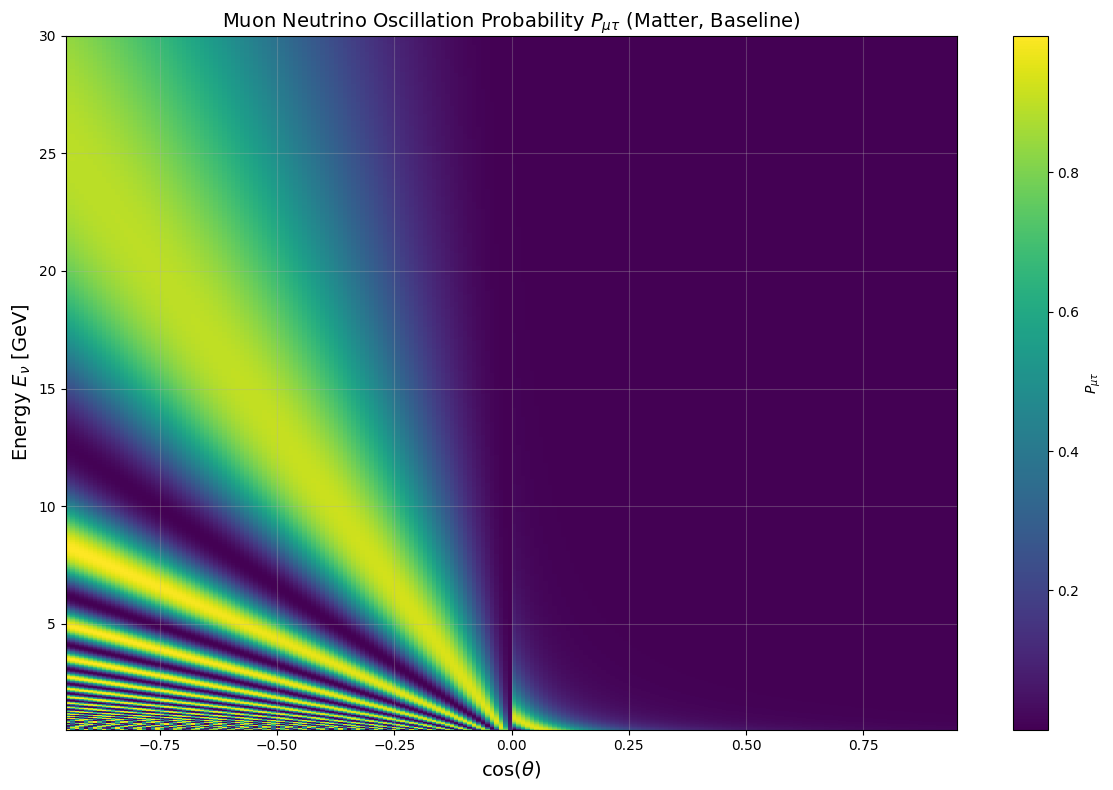

In [97]:
# Do the same thing but for baseline in km instead of cos(theta)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = p_mutau_matter(L, E, Ye=0.5, rho=2.8, baseline_type='cos')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu\tau}$ (Matter, Baseline)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu\tau}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('p_mutau_matter_oscillogram_km.pdf', dpi=300)
plt.show()

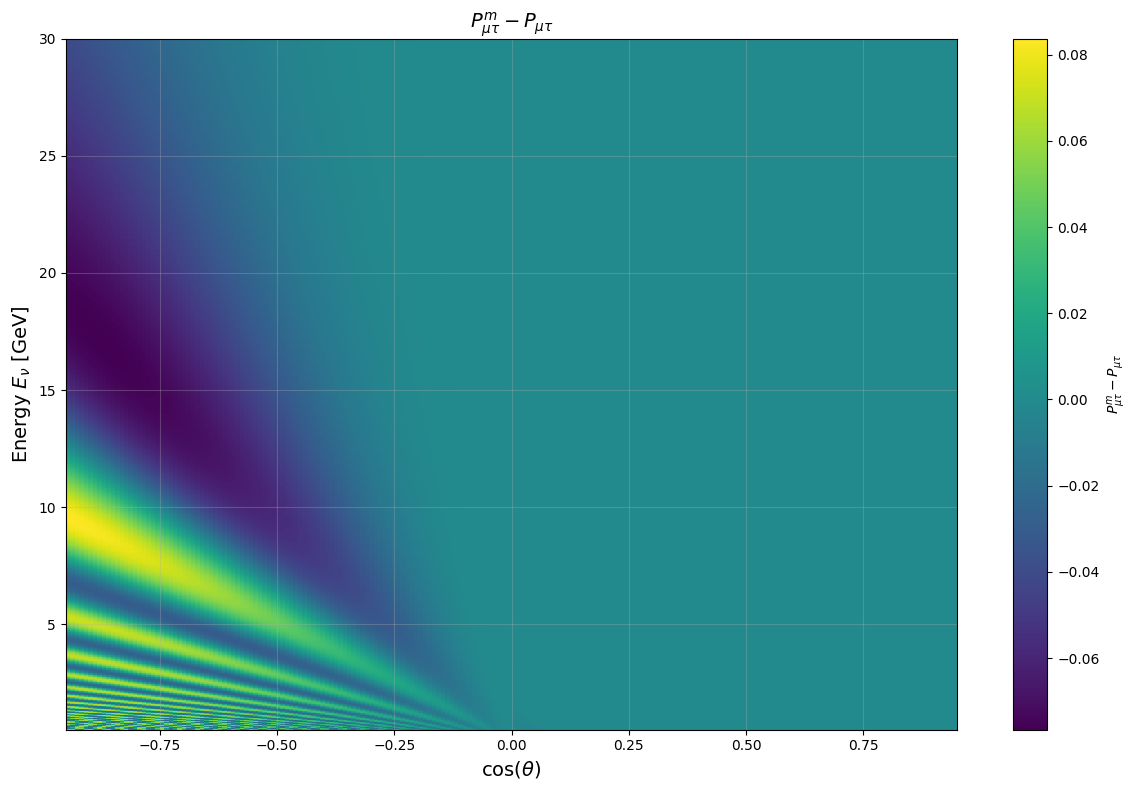

In [109]:
# Do the same thing but for baseline in km instead of cos(theta)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = p_mutau_matter(L, E, Ye=0.5, rho=2.8, baseline_type='cos')-p_mutau_vac(L, E, baseline_type='cos')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'$P_{\mu\tau}^m - P_{\mu\tau}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu\tau}^m - P_{\mu\tau}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mutau_matter_oscillogram_diff.pdf', dpi=300)
plt.show()

In [25]:
Ye = 0.5
rho = 2.8
c_213 = 1-2*s13
L = 12000
A = 7.56e-5 * Ye * rho 
print(dm31*c_213 / A)

22.58125472411187


constant L/E

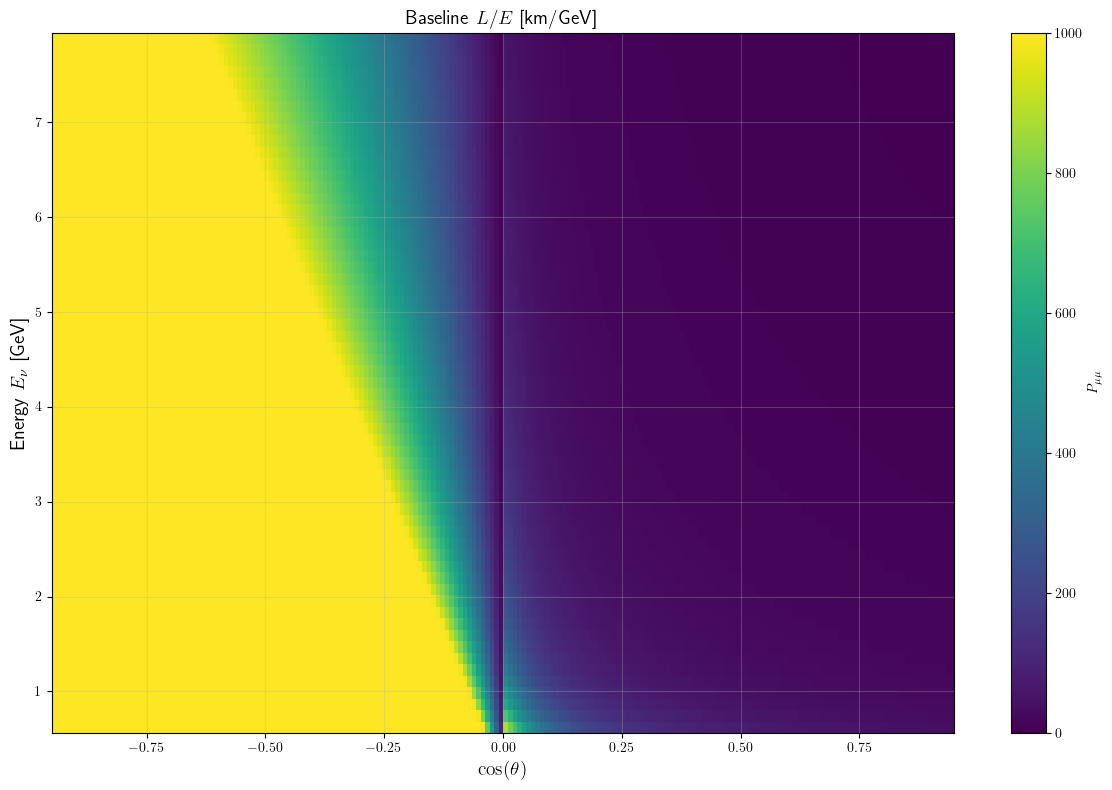

In [530]:
#from matplotlib.colors import LogNorm  
# Create heatmap: zenith angle vs energy with probability as color
energies_for_heatmap = energy_bins_centers

# Create 2D grid of L/E
base_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        base_grid[i, j] = baseline(cos_z)/E

# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(base_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest',vmin = 0, vmax = 1000)
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Baseline $L/E$ [km/GeV]', fontsize=14)

cbar = plt.colorbar(im, label=r'$P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('iso_baseline.pdf', dpi=300)
plt.show()

## Sensitivity

In [531]:
import tqdm as tqdm
Npoints = 100
s2theta = np.linspace(0.15, 0.85, Npoints)
dmSq = np.linspace(5e-4, 3e-3, Npoints)
parameter_grid = np.array(np.meshgrid(s2theta, dmSq)).T.reshape(-1, 2)
delta_theta = 20
cos_limit = cos_lim(delta_theta)
cos_grid = np.linspace(cos_limit[0], cos_limit[1], 100)

def p_mumu(cos_theta, energy, s2theta, dmSq):
    if cos_theta < 0:
        L = -2*r_e*cos_theta
    else:
        L = prop_length(cos_theta)
    return 1-4*s2theta*(1-s2theta)*np.sin(1.27*dmSq*L/energy)**2

def calculate_expected_events(s2thetaSq, dmSq):
    # allocate local arrays (avoid mutating globals)
    ev = np.zeros(len(energy_bins_centers))
    ev_un = np.zeros(len(energy_bins_centers))
    for i, E in enumerate(energy_bins_centers):
        flux_values = np.array([get_flux(cos, E)[0] for cos in cos_grid])
        osc_prob = np.array([p_mumu(cos, E, s2thetaSq, dmSq) for cos in cos_grid])
        integrand_osc = flux_values * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
        integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
        ev[i] = simpson(integrand_osc, cos_grid)
        ev_un[i] = simpson(integrand_unosc, cos_grid)
    return ev, ev_un


# def chi_squared(s2thetaSq, dmSq):
#     expected_events, bkg = calculate_expected_events(s2thetaSq, dmSq)
#     expected_events[expected_events == 0] = 1e-10
    
#     chi2 = np.sum((expected_events)**2 / bkg)
#     return chi2

# choose truth
s2_true = 0.55
dm_true = 2.44e-3

data, _ = calculate_expected_events(s2_true, dm_true)
data = data.copy()

def chi_squared(s2thetaSq, dmSq):
    pred, bkg = calculate_expected_events(s2thetaSq, dmSq)
    chi2 = np.sum((pred - data)**2 / data)
    #print(f"s2theta: {s2thetaSq:.3f}, dmSq: {dmSq:.3e}, chi2: {chi2:.2f}")
    return chi2


chi2_grid = np.zeros((Npoints, Npoints))
for i, s2 in enumerate(tqdm.tqdm(s2theta)):
    for j, dm in enumerate(dmSq):
        chi2_grid[i, j] = chi_squared(s2, dm)



 12%|█▏        | 12/100 [01:42<12:30,  8.53s/it]


KeyboardInterrupt: 

In [ ]:
nova_data = np.loadtxt('NOvA2024.dat', delimiter=',')

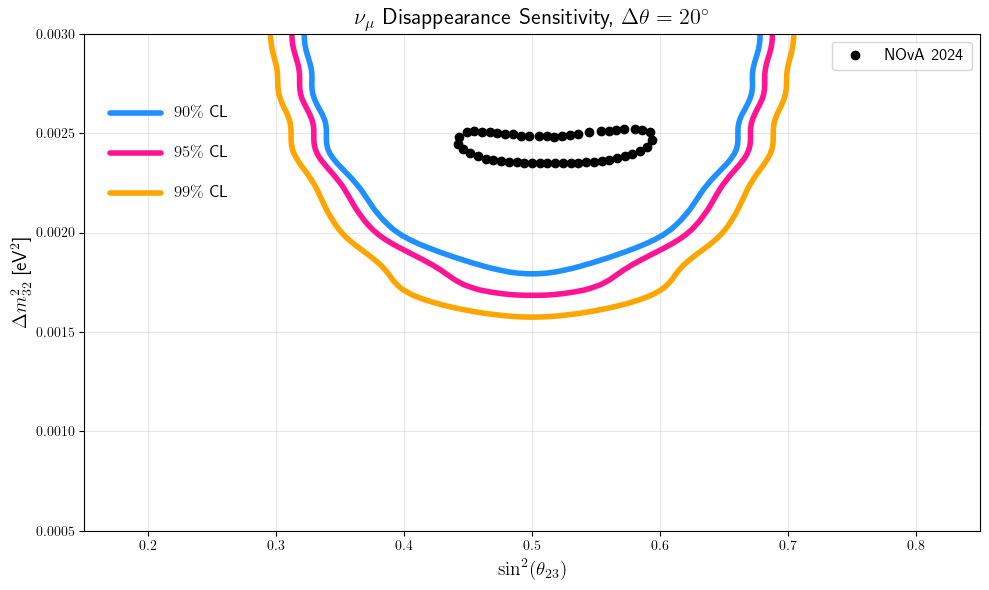

In [ ]:
# Plot chi-squared contours
# 90% CL for 2 parameters is 4.61, 95% CL is 5.99, 99% CL is 9.21
levels = [4.61, 5.99, 9.21] 
colors = ['dodgerblue', 'deeppink', 'orange']
plt.figure(figsize=(10, 6))
S2, DM = np.meshgrid(s2theta, dmSq)
CS = plt.contour(S2, DM, chi2_grid.T-np.min(chi2_grid), levels=levels, colors=colors, linewidths=4)
# plt.xlim(0.4, 0.6)
#plt.yscale('log')
#plt.ylim(2.35e-3, 2.6e-3)
#plt.ylim(5e-4, 1.5e-3)
plt.xlabel(r'$\sin^2(\theta_{23})$', fontsize=14)
plt.ylabel(r'$\Delta m^2_{32}$ [eV$^2$]', fontsize=14)

# Colored line swatches with black text labels
x0 = 0.17
x1 = 0.21
label_y = [2.6e-3, 2.4e-3, 2.2e-3]
labels = [r'$90\%$ CL', r'$95\%$ CL', r'$99\%$ CL']
for y, color, label in zip(label_y, colors, labels):
    plt.plot([x0, x1], [y, y], color=color, linewidth=4, solid_capstyle='round')
    plt.text(x1 + 0.01, y, label, fontsize=12, va='center', color='black')

# Add NOvA contour
nova_s2 = nova_data[:, 0]
nova_dm = nova_data[:, 1]/1e3
plt.plot(nova_s2, nova_dm, 'o', color='black', label='NOvA 2024')
plt.legend(fontsize=12)
plt.title(rf'$\nu_\mu$ Disappearance Sensitivity, $\Delta \theta = {delta_theta}^\circ$', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'chi_squared_contours_delta_theta_{delta_theta}.pdf', dpi=300)
plt.show()


## Matter effect spectrum

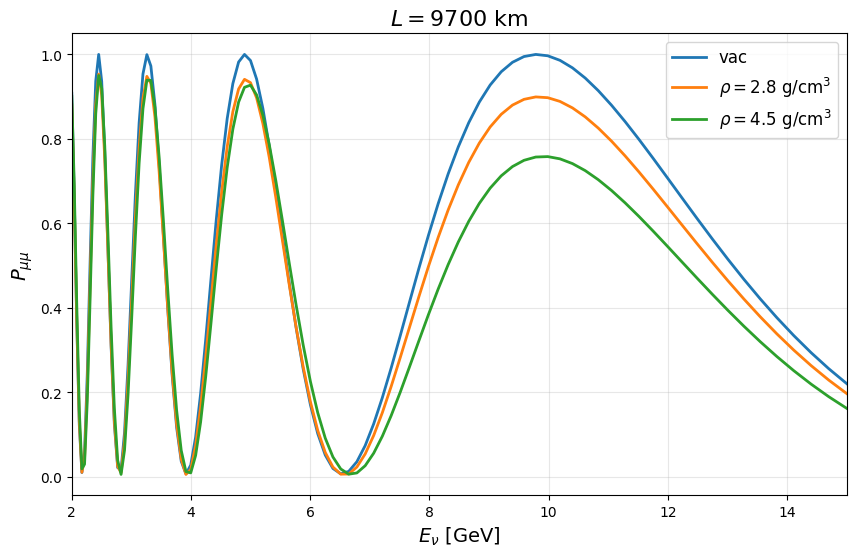

In [117]:
rho_list = [2.8, 4.5]  # g/cm^3
energy_list = np.geomspace(2, 15, 100)
p_mumu_list = np.array([p_mumu_vac(x = 9700, E=i, baseline_type='km') for i in energy_list])

plt.figure(figsize=(10, 6))
plt.plot(energy_list, p_mumu_list, label=r'vac', linewidth=2)
for rho in rho_list:
    p_mumu_matter_list = np.array([p_mumu_matter(x = 9700, E=i, Ye = 0.5, rho = rho, baseline_type='km') for i in energy_list])
    plt.plot(energy_list, p_mumu_matter_list, label=r'$\rho = %.1f$ g/cm$^3$' % rho, linewidth=2)
plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(2, 15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(rf'$L = 9700$ km', fontsize=16)
plt.savefig(f"p_mumu_matter_9700km.pdf", dpi=300)

## Same baseline and energy, but different matter density

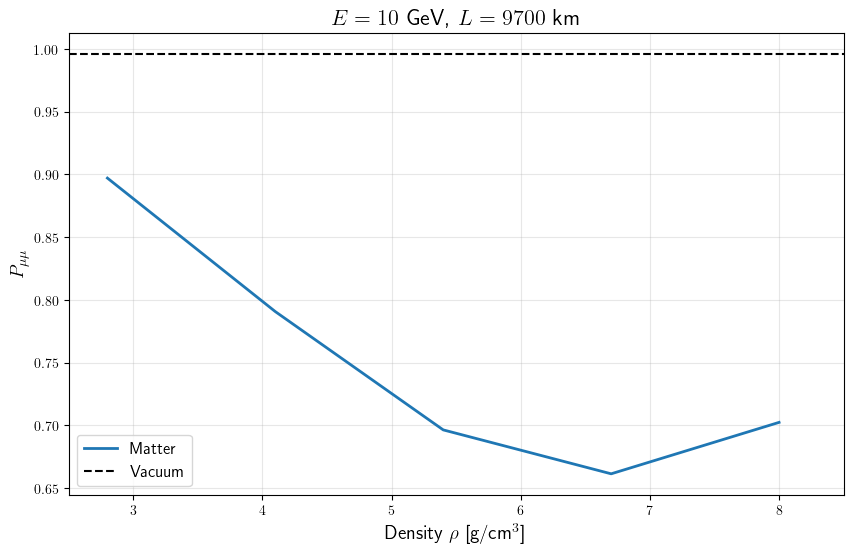

In [ ]:
rho_list = np.linspace(2.8, 8, 5)  # g/cm^3
energy = 10
baseline = 9700
p_mumu_vacuum = p_mumu_vac(x = baseline, E=energy, baseline_type='km')
p_mumu_matter_list = np.array([p_mumu_matter(energy, x = baseline, Ye = 0.5, rho = rho, baseline_type='km') for rho in rho_list])
plt.figure(figsize=(10, 6))
plt.plot(rho_list, p_mumu_matter_list, label=r'Matter', linewidth=2)
plt.axhline(p_mumu_vacuum, color='black', linestyle='--', label='Vacuum')
plt.xlabel(r"Density $\rho$ [g/cm$^3$]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(2.5, 8.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(rf'$E = {energy}$ GeV, $L = {baseline}$ km', fontsize=16)
plt.savefig(f"p_mumu_matter_vs_density.pdf", dpi=300)

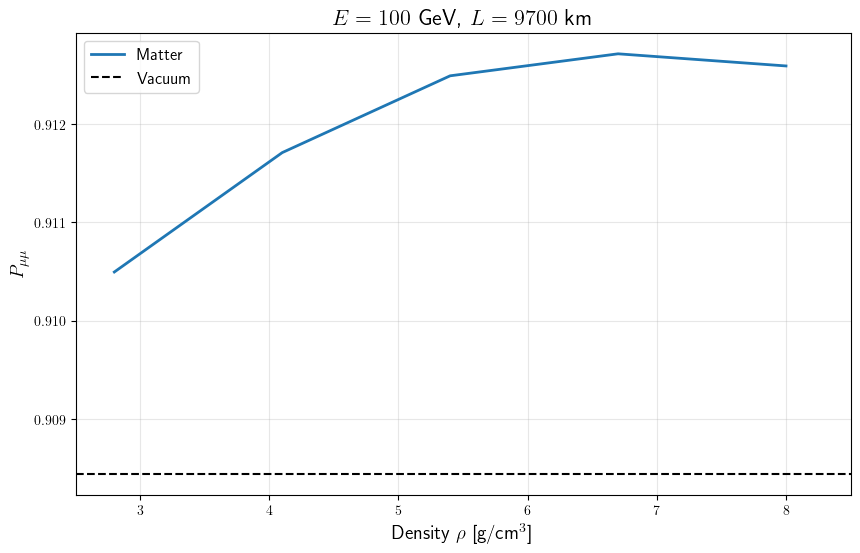

In [ ]:
rho_list = np.linspace(2.8, 8, 5)  # g/cm^3
energy = 100
baseline = 9700
p_mumu_vacuum = p_mumu_vac(x = baseline, E=energy, baseline_type='km')
p_mumu_matter_list = np.array([p_mumu_matter(energy, x = baseline, Ye = 0.5, rho = rho, baseline_type='km') for rho in rho_list])
plt.figure(figsize=(10, 6))
plt.plot(rho_list, p_mumu_matter_list, label=r'Matter', linewidth=2)
plt.axhline(p_mumu_vacuum, color='black', linestyle='--', label='Vacuum')
plt.xlabel(r"Density $\rho$ [g/cm$^3$]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(2.5, 8.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(rf'$E = {energy}$ GeV, $L = {baseline}$ km', fontsize=16)
plt.savefig(f"p_mumu_matter_vs_density.pdf", dpi=300)

In [110]:
p_mumu_matter(1300,2.5, Ye = 0.5, rho =2.8, baseline_type='km')

np.float64(0.01363702065668598)